# Plotting Vocabulary Tour

Every picture myflopy draws comes from **six verbs**, and everything they return
answers **the same four output methods**. This notebook is the whole vocabulary
in one place — what the verbs are, where they live, and the two or three rules
that decide which one you want.

The normative reference is [`docs/view_layer_conventions.md`](../../../docs/view_layer_conventions.md);
this is the runnable version of it.

In [ ]:
import sys
from pathlib import Path

# Make the in-repo `src/` importable when myflopy is not pip-installed.
src = Path.cwd().parents[2] / 'src'
if src.exists() and str(src) not in sys.path:
    sys.path.insert(0, str(src))

from IPython.display import display

import myflopy as mf
from myflopy import plot, viz
from canonical_notebook_style import notebook_header

notebook_header('PV', 'Plotting Vocabulary Tour',
                'Six verbs, four scopes, one output contract — the whole drawing API.')

root = Path('../artifacts/plotting_vocabulary')

# The smallest contract-complete model, so this notebook stays fast.
config = mf.CanonicalModelConfig.testing()
model = mf.build_canonical_model(root / 'gwf', config=config)
assert model.run_simulation()[0]
vor = model.vor
print(f'{vor.ncpl} cells x {config.nlay} layers, {len(model.kstpkper)} output times')

## The three layers

| Layer | What it is | Verbs |
|---|---|---|
| **1 — Pictures** | one drawing of one subject | `map` `section` `surface` `grid` |
| **2 — Composition** | combines finished pictures | `mosaic` `animate` |
| **3 — Output** | what you do with any picture | `.fig` `.show()` `.save(p)` `.html(p)` |

Two rules decide everything below:

1. **Geometry chooses the Layer-1 verb** — not content, not renderer. A map is a
   plan view whatever is drawn on it, so contours, well markers and pathlines are
   *options* on `map`, never verbs of their own.
2. **`backend=` switches the renderer, never the subject.**

## Layer 1 · Pictures

### `map` — a plan view

`values=` takes any per-cell array, which is what makes this the single map verb
rather than one function per quantity.

In [ ]:
heads = model.hds.array(layer=0)

model.plot.map(layer=0)                      # the model's own heads
model.plot.map(values=heads, layer=0)        # ...or any per-cell array you have

Content is an *option*, never a separate call:

In [ ]:
model.plot.map(layer=0, contours=True, contour_levels=8)

### `section` — a vertical slice

Through a **model** it is the results section; through a bare **grid** it is the
geometry. Two classes, because they answer different questions.

In [ ]:
model.hds.map()

In [ ]:
from shapely.geometry import LineString

xmin, ymin, xmax, ymax = vor.gdf_vorPolys.total_bounds
line = LineString([(xmin, (ymin + ymax) / 2), (xmax, (ymin + ymax) / 2)])

display(model.plot.section(cells=[0, 1, 2]))   # results along cells
vor.plot.section(line)                          # layer geometry along a line

### `surface` — a 3-D height field

`surface` means `z(x, y)`. That precision matters: the 3-D *volume* is a
different shape, and lives on `grid` instead (next section).

In [ ]:
model.plot.surface(layer=0)

### `grid` — the mesh itself

The one picture `map` cannot give you. A choropleth draws over a web basemap and
so **requires a CRS**; the mesh view needs none, which makes it the view for a
grid you are still refining, before a model or a projection exists.

In [ ]:
vor.plot.grid()          # or just vor.plot() -- the shorthand
vor.plot.grid().plot_mpl()   # FloPy's own renderer, still right there

## Layer 2 · Composition

`mosaic` and `animate` are **combinators**: their first argument is a collection
of finished pictures, not a subject. That is the one place the "first argument is
the subject" rule does not apply — they have no subject.

In [ ]:
panels = [(f'layer {k}', model.plot.map(layer=k)) for k in range(config.nlay)]
plot.mosaic(panels, ncols=2)

`animate` has two backends, both drawing the same frames:

* **`"plotly"`** (default) — one live figure with play/pause and a slider. Fast
  and interactive, but every frame must share a trace structure, and a choropleth
  re-embeds its geometry per frame, so the file grows with cells × frames.
* **`"png"`** — each frame rasterized and paged by a browser slider. Frames need
  share *nothing*, and the size does not grow with cell count.

In [ ]:
frames = [(f'period {i}', model.plot.map(per=i, layer=0))
          for i in range(len(model.kstpkper))]

animation = plot.animate(frames)
print(f'{len(animation.fig.frames)} frames, labels: {animation.labels[:3]} ...')
animation

Because the raster backend rasterizes each frame independently, it can hold
pictures of **different kinds** in one animation — which no single plotly figure
can do:

In [ ]:
mixed = [
    ('a map',     model.plot.map(layer=0)),
    ('a section', model.plot.section(cells=[0, 1, 2])),
]
paged = plot.animate(mixed, backend='png')
paged.html(root / 'mixed.html')

Asking the plotly backend for that **raises** rather than quietly falling back —
swapping an interactive figure for a raster page changes *what you get*, not just
how it is drawn:

In [ ]:
try:
    plot.animate(mixed, backend='plotly').fig
except ValueError as error:
    print(error)

## Layer 3 · Output

Whatever verb produced it, every picture answers the same four things. You never
learn per-class output methods, and there is never a trailing `.plot()`.

In [ ]:
picture = model.plot.map(layer=0)

print('is a Picture :', isinstance(picture, viz.Picture))
picture.fig.update_layout(title='edited in place')   # the figure, to adjust
print('title kept   :', picture.fig.layout.title.text)   # ...and it stays

picture.save(root / 'heads.html')      # suffix picks the format
picture.html(root / 'heads2.html')     # or be explicit
print('written      : heads.html, heads2.html')

### Three renderers, one contract

Most pictures are Plotly. Two are not, and they say so rather than handing back
something that looks like a Plotly figure and is not:

| Class | Native renderer | Instead of `.fig` |
|---|---|---|
| `MplPicture` | Matplotlib | `.axes` |
| `VtkScene` | PyVista | `.scene` |
| `SliderAnimation` | rasterized frames | `.frames` |

In [ ]:
section = model.plot.section(cells=[0, 1, 2])
print('plotly section .fig ->', type(section.fig).__name__)

try:
    paged.fig
except TypeError as error:
    print('\nrasterized animation .fig ->', error)

## The four scopes

The same verbs are bound wherever they make sense. Which subset a scope answers
depends on what that scope can *know* — a bare grid has no results, a layer stack
has no time.

| scope | verbs |
|---|---|
| `myflopy.plot` | `map` `section` `surface` `grid` `mosaic` `animate` |
| `model.plot` | all six |
| `vor.plot` | `map` `section` `grid` |
| `stack.plot` | `map` `section` `surface` `grid` |

The bound form *calls* the free one, so the two spellings cannot diverge:

In [ ]:
import inspect

for scope, obj in [('module', plot), ('model', type(model.plot)), ('grid', type(vor.plot))]:
    if inspect.ismodule(obj):
        verbs = sorted(n for n in obj.__all__ if n[0].islower())
    else:
        verbs = sorted(n for n, _ in inspect.getmembers(obj, inspect.isfunction)
                       if not n.startswith('_'))
    print(f'{scope:8s} {verbs}')

## Layer geometry

A `LayerStack` answers the geometry verbs too — including the 3-D mesh, where
`backend="vtk"` switches only the renderer:

In [ ]:

display(built.plot.map())          # thickness, basemap-free by dstack_root = root / 'layers'
stack = (mf.LayerStack(vor, top=mf.Flat(60.0))
         .add('sand', bottom=mf.Flat(40.0))
         .add('clay', bottom=mf.Flat(25.0)))
built = stack.build()

display(built.plot.map())          # thickness, basemap-free by default
display(built.plot.section(y=(vor.gdf_vorPolys.total_bounds[1]
                              + vor.gdf_vorPolys.total_bounds[3]) / 2))
built.plot.surface('all')

```python
built.plot.grid(backend='vtk')     # the layered volume, interactive 3-D
```

Left as a code comment because it needs the `viz3d` extra (`pip install
'myflopy[viz3d]'`) and writes a ~1 MB scene.

## What the vocabulary deliberately excludes

| Not a verb | Because |
|---|---|
| `contours` | something drawn *on* a map → `map(contours=True)` |
| `plot3d` | a 3-D view is a `surface`, or a `grid` in 3-D |
| `map_nodes` | a map whose values are node ids → `map(values=...)` |
| `timeseries` | a chart belongs to a node, which knows the model's periods |

That last one is the grammar's job — `model.packages.<pkg>.<inputs|results>.<noun>.<verb>()`:

In [ ]:
model.packages.ghb.results.q.plot()

In [18]:
scene: mf.viz.VtkScene = built.plot.grid(backend='vtk')

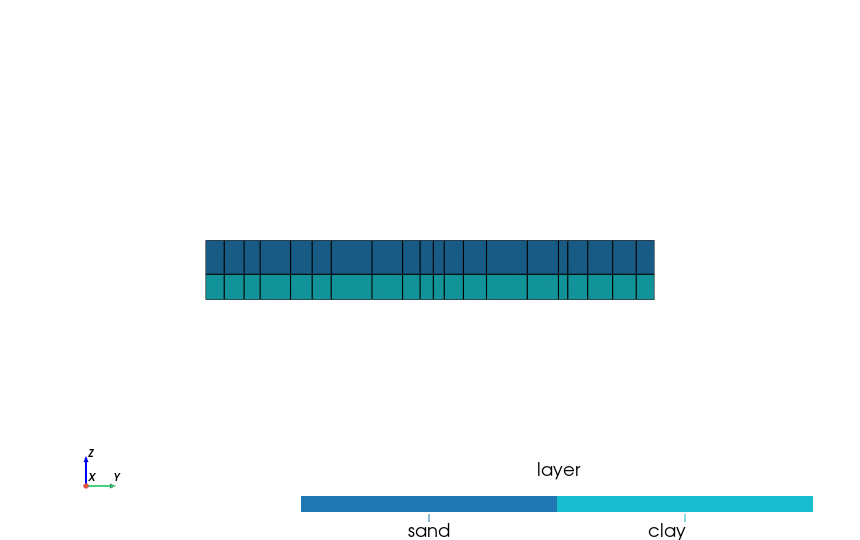

In [21]:
scene.show

## Where to go next

* [`docs/view_layer_conventions.md`](../../../docs/view_layer_conventions.md) — the normative rules
* [`docs/package_api_reference.md`](../../../docs/package_api_reference.md) — the per-package grammar
* `canonical_02_visual_diagnostics.ipynb` — these verbs used in anger, on real hydrogeology